# **Feature Engineering & NLP**
**Project**: Airbnb Market Segmentation Analysis \
**Goal**: Build the clustering-ready feature set from `listings_clean` (structural + domain-driven features, encoded for K-Prototypes), then extend it with NLP-derived signals from listing text & reviews text data.

## 1. Imports & environment setup

In [1]:
import pandas as pd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

## 2. Data Loading

In [3]:
listings_clean = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_clean.csv')
reviews_clean = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_clean.csv')

#### 2.1 Listings dataframe

In [4]:
listings_clean.shape

(35818, 72)

In [5]:
listings_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 35818 entries, 0 to 35817
Data columns (total 72 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  35818 non-null  int64  
 1   host_id                             35818 non-null  int64  
 2   host_response_time                  35818 non-null  str    
 3   host_response_rate_raw              29444 non-null  float64
 4   host_acceptance_rate_raw            32319 non-null  float64
 5   host_is_superhost                   35818 non-null  int64  
 6   host_neighbourhood                  35818 non-null  str    
 7   host_listings_count                 35818 non-null  float64
 8   host_total_listings_count           35818 non-null  float64
 9   host_has_profile_pic                35818 non-null  int64  
 10  host_identity_verified              35818 non-null  int64  
 11  neighbourhood_cleansed              35818 non-null  

In [6]:
listings_clean.describe(include = 'all')

,id,host_id,host_response_time,host_response_rate_raw,host_acceptance_rate_raw,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,...,review_scores_accuracy_binned,review_scores_cleanliness_binned,review_scores_checkin_binned,review_scores_communication_binned,review_scores_location_binned,review_scores_value_binned,host_acceptance_rate_binned,host_response_rate_binned,reviews_per_month_binned,last_review_recency_binned
count,3.581800e+04,3.581800e+04,35818,29444.000000,32319.000000,35818.000000,35818,35818.000000,35818.000000,35818.000000,...,35818,35818,35818,35818,35818,35818,35818,35818,35818,35818
unique,NaN,NaN,5,NaN,NaN,NaN,100,NaN,NaN,NaN,...,3,3,3,3,3,3,3,3,4,4
top,NaN,NaN,within an hour,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,...,Above Average,Above Average,Above Average,Above Average,Above Average,Below Average,Full Acceptance,Full Response,Moderate Demand,Active
freq,NaN,NaN,25098,NaN,NaN,NaN,24751,NaN,NaN,NaN,...,21507,20021,24267,24935,17700,16983,21295,24628,14132,20557
mean,7.541191e+17,2.666308e+08,NaN,0.966612,0.926700,0.399213,NaN,9.286867,11.760902,0.939835,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,5.746268e+17,2.439774e+08,NaN,0.136872,0.201959,0.489743,NaN,20.757329,29.960408,0.237796,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.183400e+04,2.353000e+03,NaN,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4.020579e+07,3.129867e+07,NaN,1.000000,0.980000,0.000000,NaN,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.565242e+17,1.901475e+08,NaN,1.000000,1.000000,0.000000,NaN,3.000000,3.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.271719e+18,5.070057e+08,NaN,1.000000,1.000000,1.000000,NaN,7.000000,8.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.2 Reviews dataframe

In [7]:
reviews_clean.shape

(2193159, 5)

In [8]:
reviews_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2193159 entries, 0 to 2193158
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   listing_id      int64
 1   date            str  
 2   reviewer_id     int64
 3   comments_clean  str  
 4   review_length   int64
dtypes: int64(3), str(2)
memory usage: 83.7 MB


In [9]:
reviews_clean.describe(include = 'all')

,listing_id,date,reviewer_id,comments_clean,review_length
count,2.193159e+06,2193159,2.193159e+06,2193122,2.193159e+06
unique,NaN,5242,NaN,2123477,NaN
top,NaN,2025-06-15,NaN,unknown,NaN
freq,NaN,3059,NaN,4095,NaN
mean,2.786878e+17,NaN,1.988891e+08,NaN,2.691474e+02
std,4.496488e+17,NaN,1.838524e+08,NaN,2.415132e+02
min,2.737000e+03,NaN,4.600000e+01,NaN,1.000000e+00
25%,9.950970e+06,NaN,4.574545e+07,NaN,1.030000e+02
50%,2.920817e+07,NaN,1.344770e+08,NaN,2.050000e+02
75%,6.590309e+17,NaN,3.235598e+08,NaN,3.600000e+02


## 3. Feature Engineering

- Columns that are ignored on this stage, but will be processed during the NLP step + price that will be used in later analysis

In [10]:
# text fields 
nlp_reserved_cols = [
    'name_cleaned', 'description_cleaned',
    'neighborhood_overview_cleaned', 'host_about_cleaned'
]

# raw amenities tag list
amenities_raw_col = 'amenities_tags'

# price and anything derived from it stays out of the clustering feature set
price_reserved_col = 'price'

### 3.1 High-cardinality & Imbalanced Categoricals

- `property_type`

In [11]:
# display unique categories of the property_type variable
pd.set_option('display.max_rows', None)
for cat, count in listings_clean['property_type'].value_counts().items():
    print(f"{cat}: {count}")
pd.reset_option('display.max_rows')

Entire rental unit: 17862
Entire condo: 5725
Private room in rental unit: 3567
Private room in bed and breakfast: 2271
Entire vacation home: 1372
Private room in condo: 1093
Entire home: 949
Entire loft: 414
Private room in serviced apartment: 314
Room in hotel: 310
Room in boutique hotel: 289
Private room in home: 280
Entire serviced apartment: 220
Room in bed and breakfast: 174
Private room in guesthouse: 124
Private room in vacation home: 122
Tiny home: 88
Entire villa: 70
Private room in villa: 54
Shared room in rental unit: 53
Room in aparthotel: 51
Room in serviced apartment: 50
Private room in guest suite: 47
Private room: 41
Entire guest suite: 34
Entire townhouse: 28
Private room in hostel: 26
Shared room in hostel: 15
Entire guesthouse: 14
Private room in casa particular: 13
Private room in loft: 12
Entire place: 11
Room in hostel: 11
Shared room in guesthouse: 10
Private room in castle: 10
Shared room in home: 9
Entire cabin: 7
Private room in tiny home: 7
Casa particular: 7

`property_type` is mapped from 63 raw categories into 6 macro-groups using pattern-based rules, since most raw labels follow a consistent `[privacy tier] in [property style]` structure. Keyword and prefix patterns identify *commercial/hospitality stays* (hotels, B&Bs, hostels), *leisure-oriented standalone properties* (villas, cabins, cottages), and *rare/unique stays* (boats, castles, domes), with **privacy tier** (shared/private/entire) as the fallback for everything else.

In [12]:
# ordered rules: first matching pattern wins & order matters
property_type_rules = [
    (r'^Shared room', 'Shared room'),
    (r'bed and breakfast|hostel|casa particular|farm stay|minsu', 'B&B/Hotel-type'),
    (r'vacation home|villa|cabin|cottage|chalet|bungalow|tiny home', 'Vacation home/villa'),
    (r'boat|tower|castle|dome|camper|windmill|cave|nature lodge', 'Unique/boutique'),
    (r'^Room in', 'B&B/Hotel-type'),
    (r'^Private room', 'Private room'),
    (r'^Entire', 'Entire home/apt'),
]

def map_property_type(value):
    for pattern, label in property_type_rules:
        if re.search(pattern, value, flags=re.IGNORECASE):
            return label
    return None  # flags anything unmatched 

listings_clean['property_type_grouped'] = listings_clean['property_type'].apply(map_property_type)

# sanity check if there are any unmatched categories
unmapped = listings_clean.loc[listings_clean['property_type_grouped'].isna(), 'property_type'].unique()
print("Unmapped categories:", unmapped)

grouped_counts = listings_clean['property_type_grouped'].value_counts()
grouped_pct = listings_clean['property_type_grouped'].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({'count': grouped_counts, 'pct': grouped_pct}))

Unmapped categories: <StringArray>
[]
Length: 0, dtype: str


,count,pct
property_type_grouped,,
Entire home/apt,25258,70.5
Private room,5482,15.3
B&B/Hotel-type,3215,9.0
Vacation home/villa,1732,4.8
Shared room,98,0.3
Unique/boutique,33,0.1


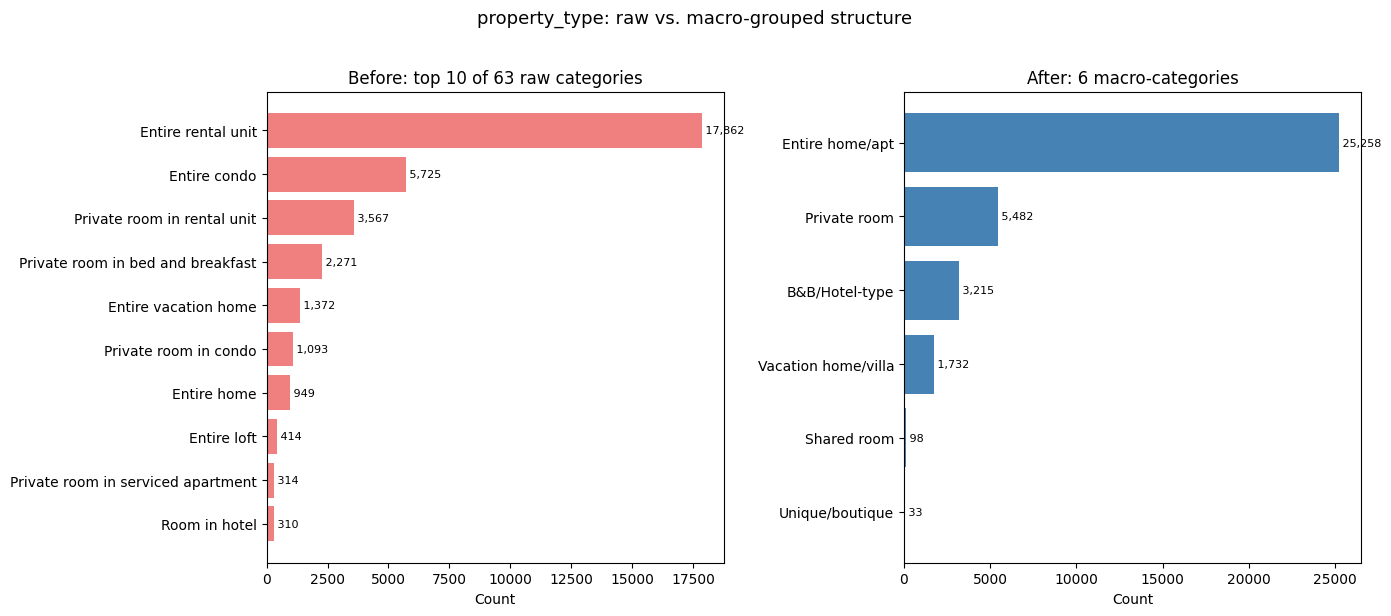

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# before: top 10 raw categories
top_raw = listings_clean['property_type'].value_counts().head(10)
axes[0].barh(top_raw.index[::-1], top_raw.values[::-1], color='lightcoral')
axes[0].set_title(f'Before: top 10 of {listings_clean["property_type"].nunique()} raw categories')
axes[0].set_xlabel('Count')

# after: 6 macro-groups
grouped_counts_sorted = grouped_counts.sort_values()
axes[1].barh(grouped_counts_sorted.index, grouped_counts_sorted.values, color='steelblue')
axes[1].set_title(f'After: {listings_clean["property_type_grouped"].nunique()} macro-categories')
axes[1].set_xlabel('Count')

for ax in axes:
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(v, i, f' {int(v):,}', va='center', fontsize=8)

plt.suptitle('property_type: raw vs. macro-grouped structure', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Shared room** and **Unique/boutique** are very small groups but are deliberately kept separate rather than folded into a larger category: `Shared room` reflects a materially different privacy tier from `Private room`, and `Unique/boutique` groups property styles that are conceptually distinct from standard residential stays.

- `neighbourhood_cleansed`

In [14]:
# inspect distribution
neighbourhood_counts = listings_clean['neighbourhood_cleansed'].value_counts()
neighbourhood_pct = listings_clean['neighbourhood_cleansed'].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({'count': neighbourhood_counts, 'pct': neighbourhood_pct}))

,count,pct
neighbourhood_cleansed,,
I Centro Storico,17537,49.0
VII San Giovanni/Cinecittà,3138,8.8
XIII Aurelia,2560,7.1
II Parioli/Nomentano,2473,6.9
XII Monte Verde,1934,5.4
V Prenestino/Centocelle,1836,5.1
VIII Appia Antica,1155,3.2
X Ostia/Acilia,1020,2.8
XIV Monte Mario,833,2.3


`neighbourhood_cleansed` consists of 15 administrative municipi, each already representing a specific, meaningful area of Rome rather than an arbitrary or overly granular label. The distribution is skewed, as `I Centro Storico` alone accounts for **49.0%** of listings, with the rest spread from 8.8% down to 0.9% across the remaining 14 categories, but since the categories themselves are specific and interpretable, no merging or grouping is applied at this stage and the variable is kept as-is. Whether it should ultimately serve as a clustering input, be replaced by a more granular geographic signal, or be reserved for profiling only is left for the upcoming EDA and feature selection stage, once the full candidate feature set can be compared directly.

### 3.2 Geographic Features

`latitude` and `longitude` are fully populated columns that can derive two useful features:
- `distance_to_center_km` — a continuous haversine distance from each listing to a fixed Rome reference point (Piazza Venezia)
- `geo_sector`, a coarse 8-direction compass sector from the same reference point, kept for interpretability during cluster profiling

In [15]:
# Rome reference point: Piazza Venezia (city center)
REFERENCE_LAT = 41.8955
REFERENCE_LON = 12.4823

def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r_earth_km = 6371
    return r_earth_km * c

listings_clean['distance_to_center_km'] = haversine_distance(
    listings_clean['latitude'], listings_clean['longitude'],
    REFERENCE_LAT, REFERENCE_LON
)

# 8-direction compass sector from the reference point
def compass_sector(lat, lon, ref_lat=REFERENCE_LAT, ref_lon=REFERENCE_LON):
    dlat = lat - ref_lat
    dlon = lon - ref_lon
    angle = (np.degrees(np.arctan2(dlon, dlat)) + 360) % 360
    sectors = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    idx = int(((angle + 22.5) % 360) // 45)
    return sectors[idx]

listings_clean['geo_sector'] = listings_clean.apply(
    lambda row: compass_sector(row['latitude'], row['longitude']), axis=1
)

display(listings_clean[['latitude', 'longitude', 'distance_to_center_km', 'geo_sector']].describe(include='all'))

,latitude,longitude,distance_to_center_km,geo_sector
count,35818.000000,35818.000000,35818.000000,35818
unique,NaN,NaN,NaN,8
top,NaN,NaN,NaN,E
freq,NaN,NaN,NaN,8674
mean,41.891025,12.480493,3.846244,NaN
std,0.035305,0.049925,4.240249,NaN
min,41.655820,12.242530,0.072973,NaN
25%,41.882890,12.459109,1.556894,NaN
50%,41.896230,12.477656,2.679963,NaN
75%,41.906500,12.505698,4.262451,NaN


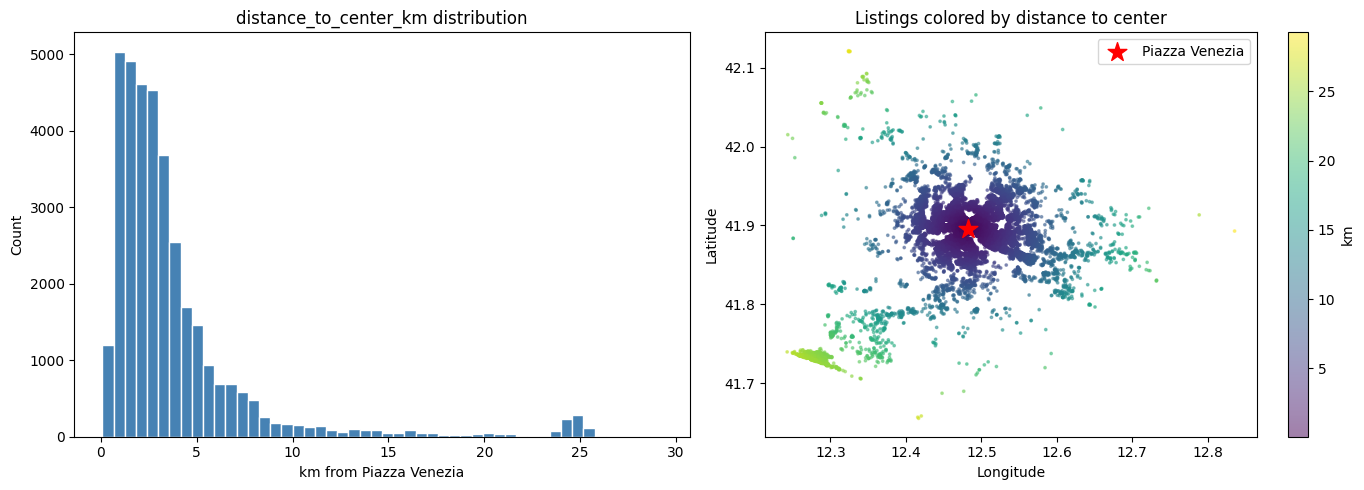

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of distance_to_center_km
axes[0].hist(listings_clean['distance_to_center_km'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('distance_to_center_km distribution')
axes[0].set_xlabel('km from Piazza Venezia')
axes[0].set_ylabel('Count')

# listings colored by distance, to visually sanity-check geography
scatter = axes[1].scatter(
    listings_clean['longitude'], listings_clean['latitude'],
    c=listings_clean['distance_to_center_km'], cmap='viridis', s=3, alpha=0.5
)
axes[1].scatter([REFERENCE_LON], [REFERENCE_LAT], color='red', marker='*', s=200, label='Piazza Venezia')
axes[1].set_title('Listings colored by distance to center')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend()
plt.colorbar(scatter, ax=axes[1], label='km')

plt.tight_layout()
plt.show()

Since `distance_to_center_km` alone only captures *how far* a listing is from the city center and not *in which direction*, `geo_sector`, a 8-direction compass bucket (N/NE/E/SE/S/SW/W/NW) computed from the same reference point, is added alongside it. Together, the two features behave like polar coordinates (radius + angle) rather than raw lat/lon, giving the clustering algorithm both a continuous distance signal and an interpretable directional one, without the granularity or imbalance issues of using coordinates or `neighbourhood_cleansed` directly.

### 3.3 Resolving Multicollinearity: Review-Score & Host-Portfolio Blocks

#### 3.3.1 Correlation & VIF Check

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_centered(df, cols):
    """Computes VIF after mean-centering to avoid inflated values."""
    X = df[cols].dropna()
    X_centered = X - X.mean() 
    vif_data = pd.DataFrame({
        'variable': cols,
        'VIF': [variance_inflation_factor(X_centered.values, i) for i in range(len(cols))]
    })
    return vif_data, X_centered

- **Review-score block** - raw, continuous & complete-case only

Review-score block: VIF computed on 30,718 rows with reviews (85.8% of dataset)


,variable,VIF
0,review_scores_rating_raw,5.98
1,review_scores_accuracy_raw,3.79
2,review_scores_cleanliness_raw,2.69
3,review_scores_checkin_raw,2.37
4,review_scores_communication_raw,2.88
5,review_scores_location_raw,1.45
6,review_scores_value_raw,4.03


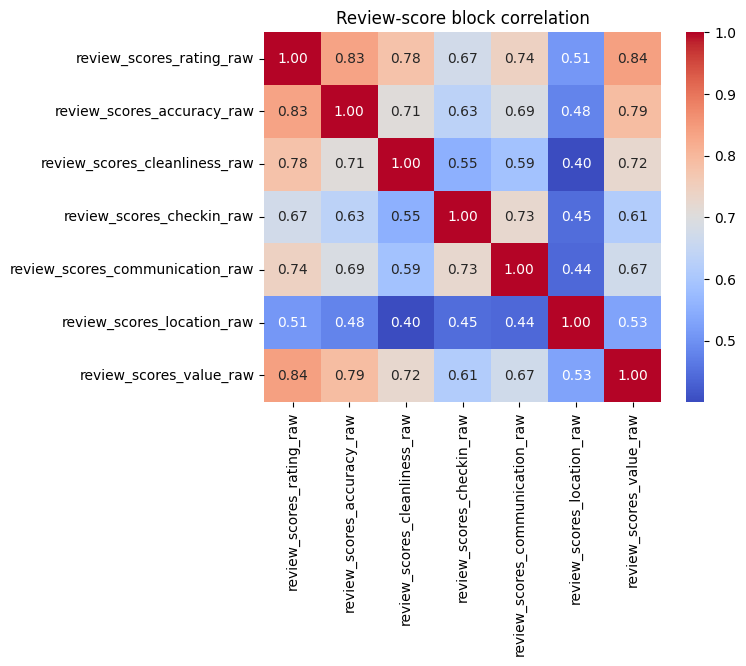

In [18]:
review_score_raw_cols = [
    'review_scores_rating_raw', 'review_scores_accuracy_raw', 'review_scores_cleanliness_raw',
    'review_scores_checkin_raw', 'review_scores_communication_raw', 'review_scores_location_raw',
    'review_scores_value_raw'
]

review_corr = listings_clean[review_score_raw_cols].corr()
review_vif, review_X = compute_vif_centered(listings_clean, review_score_raw_cols)

print(f"Review-score block: VIF computed on {len(review_X):,} rows with reviews "
      f"({len(review_X)/len(listings_clean)*100:.1f}% of dataset)")
display(review_vif.round(2))

# visualize correlations
sns.heatmap(review_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Review-score block correlation');

The correlation matrix confirms strong, systematic pairwise relationships across the entire block, with `review_scores_rating` correlating most strongly with every other variable, which is consistent with it functioning as Airbnb's own composite summary score. `review_scores_location` is the most independent variable in the block, reflecting that a listing's location is conceptually unrelated to its cleanliness or host responsiveness.

Centered VIF values are moderate rather than extreme: `review_scores_rating` and `review_scores_value` exceed the conventional VIF > 5 threshold for meaningful multicollinearity, while the remaining five variables fall between 1.45 and 3.79. No variable reaches the more severe VIF > 10 threshold. This is a more measured picture than the correlation matrix alone suggests. The block is meaningfully but not catastrophically collinear.

Given that seven variables measuring largely overlapping underlying signal would otherwise occupy a disproportionate share of the clustering feature space relative to other conceptual axes. **Dimensionality reduction for this block is still warranted**.

- **Host-portfolio block** - fully populated

Host-portfolio block: VIF computed on 35,818 rows (full dataset, no missing)


,variable,VIF
0,host_listings_count,23.09
1,host_total_listings_count,14.49
2,calculated_host_listings_count,4.78
3,host_verifications_count,2.30
4,host_experience_years,1.18
5,host_has_profile_pic,1.12
6,host_identity_verified,1.03
7,no_valid_license,1.03
8,host_verification_work_email,2.27


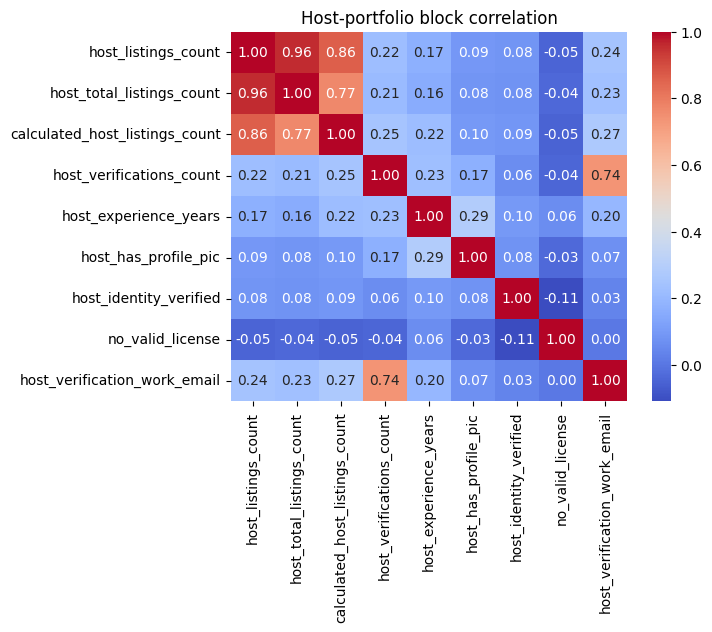

In [19]:
host_prof_cols = [
    'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count',
    'host_verifications_count', 'host_experience_years', 'host_has_profile_pic',
    'host_identity_verified', 'no_valid_license', 'host_verification_work_email'
]

host_corr = listings_clean[host_prof_cols].corr()
host_vif, host_X = compute_vif_centered(listings_clean, host_prof_cols)

print(f"Host-portfolio block: VIF computed on {len(host_X):,} rows (full dataset, no missing)")
display(host_vif.round(2))

# visualize correlations
sns.heatmap(host_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Host-portfolio block correlation');

Unlike the review-score block, the host-portfolio block does not behave as a single homogeneous cluster. Two distinct sub-groups emerge:

- **Listings-count trio** (`host_listings_count`, `host_total_listings_count`, `calculated_host_listings_count`): severe multicollinearity, with VIF of 23.09, 14.49, and 4.78 respectively, and pairwise correlations of 0.77–0.96. All three measure essentially the same underlying quantity, a host's portfolio size, via different counting methodologies.
- **Verification/establishment variables** (`host_experience_years`, `host_has_profile_pic`, `host_identity_verified`, `no_valid_license`): VIF of 1.03–1.18, with negligible pairwise correlations (0.03–0.29). These are effectively independent and each capture a distinct dimension of host trustworthiness.
- **`host_verifications_count` and `host_verification_work_email`** correlate moderately with each other (r = 0.74, VIF ≈ 2.3) but not with the rest of the block, and are kept separate rather than folded in with either group.

Since only the listings-count trio shows structural redundancy, there is no need for a PCA composite here. Instead, a single representative variable will be selected directly, and the other two will be dropped from the clustering feature set entirely, in a dedicated sub-section below.